# Entrega 2 - Preprocesamiento y EDA del corpus AG News

## Objetivo

Cargar y validar el corpus AG News, implementar un pipeline de limpieza, normalización y lematización, y realizar un análisis exploratorio técnico orientado al modelado posterior.

Esta entrega no incluye entrenamiento de modelos predictivos. Su propósito es preparar y comprender el corpus que será utilizado por el baseline clásico y el modelo Transformer.

## 1. Importación de librerías

In [1]:
# ==========================================
# Librerías estándar
# ==========================================

import os
import re
import sys
from collections import Counter

# ==========================================
# Librerías numéricas y tabulares
# ==========================================

import numpy as np
import pandas as pd

# ==========================================
# Visualización
# ==========================================

import matplotlib.pyplot as plt

# ==========================================
# Scikit-learn
# ==========================================

from sklearn.feature_extraction.text import CountVectorizer

# ==========================================
# Spacy
# ==========================================

import spacy

# ==========================================
# HTML
# ==========================================

import html

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Raíz agregada a sys.path:")
print(PROJECT_ROOT)

Raíz agregada a sys.path:
C:\proyecto_nlp_ds3\proyecto_nlp_ds3


In [3]:
# ==========================================
# Path
# ==========================================

from src.paths import (
    PROJECT_ROOT,
    DATA_RAW,
    DATA_PROCESSED,
    OUTPUTS_FIGURES,
    OUTPUTS_TABLES,
    ensure_output_directories,
)

## 2. Verificación del entorno y rutas

In [4]:
ensure_output_directories()

print("Raíz del proyecto:", PROJECT_ROOT)
print("Datos crudos:", DATA_RAW)
print("Datos procesados:", DATA_PROCESSED)
print("Figuras:", OUTPUTS_FIGURES)
print("Tablas:", OUTPUTS_TABLES)

Raíz del proyecto: C:\proyecto_nlp_ds3\proyecto_nlp_ds3
Datos crudos: C:\proyecto_nlp_ds3\proyecto_nlp_ds3\data\raw
Datos procesados: C:\proyecto_nlp_ds3\proyecto_nlp_ds3\data\processed
Figuras: C:\proyecto_nlp_ds3\proyecto_nlp_ds3\outputs\figures
Tablas: C:\proyecto_nlp_ds3\proyecto_nlp_ds3\outputs\tables


## 3. Carga del corpus AG News

In [5]:
# ==========================================
# Cargar datasets
# ==========================================

train_path = DATA_RAW / "ag_news_train.csv"
test_path = DATA_RAW / "ag_news_test.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Test:", df_test.shape)

Train: (8000, 2)
Test: (2000, 2)


## 4. Inspección inicial del corpus

In [6]:
# ==========================================
# Inspección inicial del dataset
# ==========================================

print("Columnas del conjunto de entrenamiento:")
print(df_train.columns)

print("\nPrimeros cinco registros:")
display(df_train.head())

print("\nInformación general:")
df_train.info()

Columnas del conjunto de entrenamiento:
Index(['text', 'label'], dtype='str')

Primeros cinco registros:


,text,label
0,"Red Hat Appoints New CFO. September 2, 2004 --...",Sci_Tech
1,"Sprint, SBC In Hotspot Roaming Deal. Sprint an...",Sci_Tech
2,Radio Outage Grounds West Coast Flights. Airpo...,Business
3,Hollywood lawsuits to strike Net pirates. Holl...,Sci_Tech
4,Custis Takes Control. Family and Tony Robbins ...,Sports



Información general:
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    8000 non-null   str  
 1   label   8000 non-null   str  
dtypes: str(2)
memory usage: 125.1 KB


## 5. Validación inicial del corpus

In [7]:
# ==========================================
# Validación inicial del dataset
# ==========================================

print(f"Registros de entrenamiento: {len(df_train)}")
print(f"Registros de prueba: {len(df_test)}")

print("\nValores nulos (train):")
print(df_train.isnull().sum())

print("\nValores nulos (test):")
print(df_test.isnull().sum())

print("\nCantidad de clases:")
print(df_train["label"].value_counts())

print("\nEtiquetas disponibles:")
print(df_train["label"].unique())

Registros de entrenamiento: 8000
Registros de prueba: 2000

Valores nulos (train):
text     0
label    0
dtype: int64

Valores nulos (test):
text     0
label    0
dtype: int64

Cantidad de clases:
label
Sci_Tech    2000
Business    2000
Sports      2000
World       2000
Name: count, dtype: int64

Etiquetas disponibles:
<StringArray>
['Sci_Tech', 'Business', 'Sports', 'World']
Length: 4, dtype: str


## 6. Longitud de los documentos

In [8]:
# ==========================================
# Longitud de los documentos
# ==========================================

df_train["num_words"] = df_train["text"].str.split().str.len()

print(df_train["num_words"].describe())

count    8000.000000
mean       37.962500
std         9.983026
min         8.000000
25%        32.000000
50%        38.000000
75%        43.000000
max       142.000000
Name: num_words, dtype: float64


## 7. Distribución de la longitud de los documentos

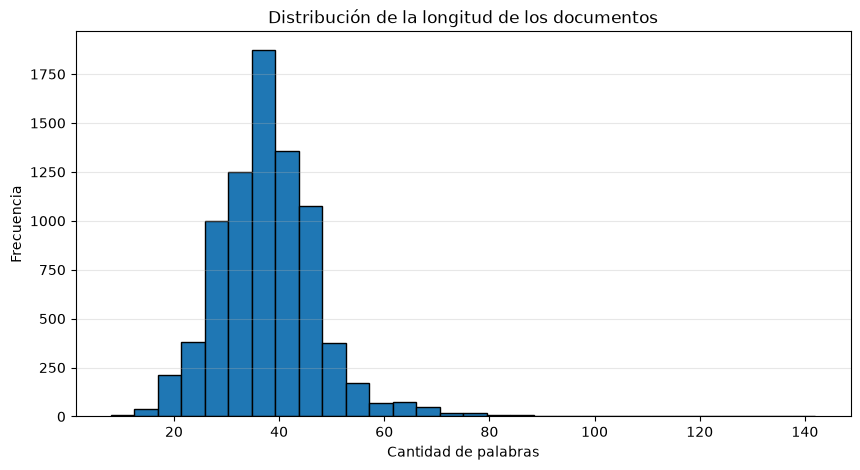

In [9]:
# ==========================================
# Histograma de longitud de documentos
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(
    df_train["num_words"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución de la longitud de los documentos")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Frecuencia")

plt.grid(axis="y", alpha=0.3)

plt.show()

## 8. Cálculo del percentil 95

In [10]:
# ==========================================
# Percentil 95 de longitud
# ==========================================

percentil_95 = np.percentile(df_train["num_words"], 95)

print(f"Percentil 95: {percentil_95:.0f} palabras")

Percentil 95: 53 palabras


## 9. Instalación y carga de spaCy

In [11]:
# ==========================================
# Instalación de spaCy
# ==========================================

import sys

!{sys.executable} -m pip install spacy

In [12]:
# ==========================================
# Descargar modelo en inglés
# ==========================================

!{sys.executable} -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----------- ---------------------------- 3.7/12.8 MB 21.8 MB/s eta 0:00:01
     ------------------------- -------------- 8.1/12.8 MB 21.0 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 20.7 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 19.6 MB/s  0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [13]:
nlp = spacy.load("en_core_web_sm")

print("spaCy:", spacy.__version__)
print("Modelo cargado correctamente.")

spaCy: 3.8.14
Modelo cargado correctamente.


## 10. Pipeline de preprocesamiento

In [14]:
# ==========================================
# Función de preprocesamiento
# ==========================================

nlp = spacy.load("en_core_web_sm")

RUIDO = {
    "lt",
    "gt",
    "afp",
    "quot",
    "href",
    "target",
    "quickinfo",
    "fullquote",
    "ap",
    "reuter",
    "reuters",
    "com",
    "www",
    "http",
    "https",
    "s",
    "u",
    "b",
    "t"
}

def preprocess_text(text):
    """
    Limpia, normaliza y lematiza un documento.
    """
    # Pasar a minúsculas
    text = text.lower()

    # Eliminar URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Decodificar entidades HTML (&lt; -> <, &gt; -> >, etc.)
    text = html.unescape(text)

    # Eliminar etiquetas HTML completas
    text = re.sub(r"<[^>]+>", " ", text)

    # Conservar solo letras y espacios
    text = re.sub(r"[^a-z\s]", " ", text)

    # Eliminar espacios múltiples
    text = re.sub(r"\s+", " ", text).strip()

    # Procesar con spaCy
    doc = nlp(text)

    tokens = []

    for token in doc:

        if token.is_stop:
            continue

        if token.is_punct:
            continue

        if token.lemma_.strip() == "":
            continue

        # Eliminar artefactos del corpus
        if token.lemma_ in RUIDO:
            continue

        tokens.append(token.lemma_)

    return " ".join(tokens)

In [15]:
ejemplo = df_train.loc[0, "text"]

print("Texto original:\n")
print(ejemplo)

print("\nTexto procesado:\n")
print(preprocess_text(ejemplo))

Texto original:

Red Hat Appoints New CFO. September 2, 2004 -- (WEB HOST INDUSTRY REVIEW) -- Linux distributor Red Hat (redhat.com) announced on Thursday that it has appointed Charles E. Peters, Jr.

Texto procesado:

red hat appoint new cfo september web host industry review linux distributor red hat redhat announce thursday appoint charles e peters jr


## 11. Aplicación del pipeline de preprocesamiento

In [16]:
# ==========================================
# Aplicación del preprocesamiento
# ==========================================

df_train["text_processed"] = df_train["text"].apply(preprocess_text)

df_test["text_processed"] = df_test["text"].apply(preprocess_text)

print("Preprocesamiento definitivo aplicado.")

display(
    df_train[
        ["text", "text_processed"]
    ].head()
)

Preprocesamiento definitivo aplicado.


,text,text_processed
0,"Red Hat Appoints New CFO. September 2, 2004 --...",red hat appoint new cfo september web host ind...
1,"Sprint, SBC In Hotspot Roaming Deal. Sprint an...",sprint sbc hotspot roam deal sprint sbc commun...
2,Radio Outage Grounds West Coast Flights. Airpo...,radio outage ground west coast flights airport...
3,Hollywood lawsuits to strike Net pirates. Holl...,hollywood lawsuit strike net pirate hollywood ...
4,Custis Takes Control. Family and Tony Robbins ...,custis take control family tony robbin mature ...


## 12. Top 50 palabras más frecuentes

In [17]:
# ==========================================
# Top 50 palabras más frecuentes
# ==========================================

texto_completo = " ".join(df_train["text_processed"])

palabras = texto_completo.split()

frecuencias = Counter(palabras)

top_50 = pd.DataFrame(
    frecuencias.most_common(50),
    columns=["Palabra", "Frecuencia"]
)

display(top_50)

,Palabra,Frecuencia
0,say,1814
1,new,1433
2,year,969
3,company,651
4,win,620
5,world,609
6,game,553
7,report,551
8,oil,519
9,monday,518


## 13. Top 20 bigramas

In [18]:
# ==========================================
# Top 20 bigramas
# ==========================================

vectorizer_bi = CountVectorizer(ngram_range=(2, 2))

X_bi = vectorizer_bi.fit_transform(df_train["text_processed"])

frecuencias_bi = (
    pd.DataFrame(
        {
            "Bigrama": vectorizer_bi.get_feature_names_out(),
            "Frecuencia": X_bi.sum(axis=0).A1,
        }
    )
    .sort_values("Frecuencia", ascending=False)
    .head(20)
)

display(frecuencias_bi)

,Bigrama,Frecuencia
77676,new york,419
80344,oil price,197
124491,united states,167
90082,prime minister,139
80117,official say,115
102382,say thursday,102
102169,say monday,101
95275,red sox,98
102395,say tuesday,98
67409,los angeles,96


### Observación metodológica — frecuencias y bigramas

El análisis inicial de frecuencias reveló la presencia de artefactos provenientes del formato original del corpus, incluyendo entidades HTML y metadatos de publicación. La inspección del texto fuente permitió identificar además etiquetas HTML almacenadas mediante entidades escapadas, por lo que el pipeline fue ajustado para decodificarlas antes de eliminar las etiquetas de formato.

Tras esta corrección, el análisis comenzó a reflejar expresiones propias del dominio periodístico, como "new york", "prime minister" y "oil price". En este punto se decidió no continuar ampliando la lista de exclusión, ya que eliminar términos adicionales implicaría intervenir sobre el contenido semántico del corpus y no sobre ruido técnico. Se consideró que el preprocesamiento había alcanzado un equilibrio adecuado entre limpieza y preservación de la información.

## 14. Top 20 trigramas

In [19]:
# ==========================================
# Top 20 trigramas
# ==========================================

vectorizer_tri = CountVectorizer(ngram_range=(3, 3))

X_tri = vectorizer_tri.fit_transform(df_train["text_processed"])

frecuencias_tri = (
    pd.DataFrame(
        {
            "Trigrama": vectorizer_tri.get_feature_names_out(),
            "Frecuencia": X_tri.sum(axis=0).A1,
        }
    )
    .sort_values("Frecuencia", ascending=False)
    .head(20)
)

display(frecuencias_tri)

,Trigrama,Frecuencia
109710,quote profile research,69
91094,new york stock,37
15183,boston red sox,37
60183,high oil price,27
105493,press canadian press,26
18611,canadian press canadian,26
106147,prime minister ariel,26
85060,minister ariel sharon,25
122908,secretary state colin,22
132514,state colin powell,22


### Observación metodológica

La inspección inicial de trigramas permitió detectar expresiones asociadas a formato HTML/CSS, como "ms sans serif" y "font face verdana". Al revisar los documentos originales se comprobó que estos residuos provenían de etiquetas HTML almacenadas mediante entidades escapadas, por ejemplo &lt;FONT ... &gt;, que la limpieza previa no reconocía como etiquetas.

Para corregir este problema se incorporó la decodificación de entidades HTML antes de eliminar las etiquetas de formato. Luego se recalcularon los n-gramas y los patrones técnicos detectados dejaron de aparecer entre los resultados principales. Los trigramas resultantes corresponden ahora a expresiones propias del contenido periodístico, como "new york stock", "high oil price", "prime minister ariel" y "security exchange commission".

A partir de esta verificación se decidió no ampliar la limpieza mediante exclusiones léxicas adicionales, preservando términos potencialmente informativos para las etapas posteriores de representación y clasificación.

## 15. Distribución de clases

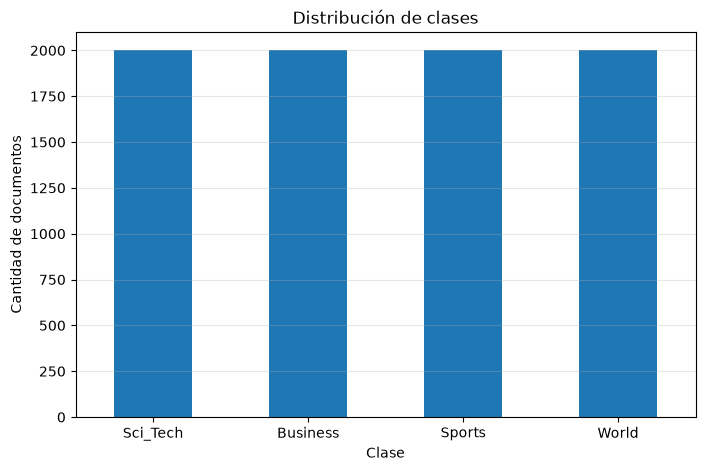

In [20]:
# ==========================================
# Distribución de clases
# ==========================================

conteo_clases = df_train["label"].value_counts()

plt.figure(figsize=(8, 5))

conteo_clases.plot(kind="bar")

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad de documentos")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

## 16. Verificación de stopwords

In [21]:
# ==========================================
# Stopwords presentes en el Top 50
# ==========================================

stopwords_top50 = top_50[
    top_50["Palabra"].apply(
        lambda palabra: nlp.vocab[palabra].is_stop
    )
]

print(f"Cantidad de stopwords en el Top 50: {len(stopwords_top50)}")

display(stopwords_top50)

Cantidad de stopwords en el Top 50: 2


,Palabra,Frecuencia
0,say,1814
45,take,316


### Observación metodológica

El análisis exploratorio fue utilizado como un mecanismo de validación del pipeline de preprocesamiento y no únicamente como una descripción del corpus. La inspección de palabras y n-gramas frecuentes permitió detectar artefactos derivados del formato original de los documentos, incluyendo entidades HTML, metadatos y residuos de etiquetas de formato.

La revisión de los documentos originales permitió determinar que parte de estos residuos provenía de etiquetas HTML almacenadas mediante entidades escapadas. En consecuencia, se incorporó una etapa de decodificación de entidades HTML previa a la eliminación de las etiquetas. Luego de aplicar la corrección y recalcular los n-gramas, expresiones técnicas como "ms sans serif" y "font face verdana" dejaron de aparecer entre los resultados principales.

Tras este refinamiento, los bigramas y trigramas más frecuentes reflejan predominantemente contenido propio del dominio periodístico, incluyendo lugares, actores políticos, organizaciones, eventos deportivos y expresiones económicas. A partir de esta verificación se decidió detener la ampliación de las reglas de limpieza, evitando eliminar términos lingüísticos legítimos únicamente por su elevada frecuencia.

## 17. Persistencia de artefactos

In [25]:
# ==========================================
# Guardar corpus procesado
# ==========================================

df_train.to_csv(
    DATA_PROCESSED / "ag_news_train_processed_limpio.csv",
    index=False
)

df_test.to_csv(
    DATA_PROCESSED / "ag_news_test_processed_limpio.csv",
    index=False
)

In [22]:
# ==========================================
# Guardar tablas
# ==========================================

top_50.to_csv(
    OUTPUTS_TABLES / "top_50_palabras.csv",
    index=False
)

frecuencias_bi.to_csv(
    OUTPUTS_TABLES / "top_20_bigramas.csv",
    index=False
)

frecuencias_tri.to_csv(
    OUTPUTS_TABLES / "top_20_trigramas.csv",
    index=False
)

print("Tablas guardadas.")

Tablas guardadas.


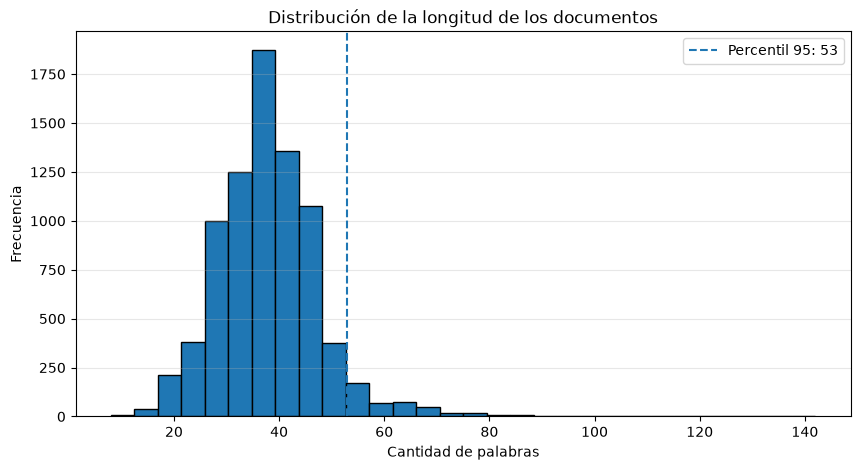

In [23]:
# ==========================================
# Guardar figuras
# ==========================================

fig = plt.figure(figsize=(10, 5))

plt.hist(
    df_train["num_words"],
    bins=30,
    edgecolor="black"
)

plt.axvline(
    percentil_95,
    linestyle="--",
    label=f"Percentil 95: {percentil_95:.0f}"
)

plt.title("Distribución de la longitud de los documentos")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(axis="y", alpha=0.3)

fig.savefig(
    OUTPUTS_FIGURES / "distribucion_longitud_documentos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

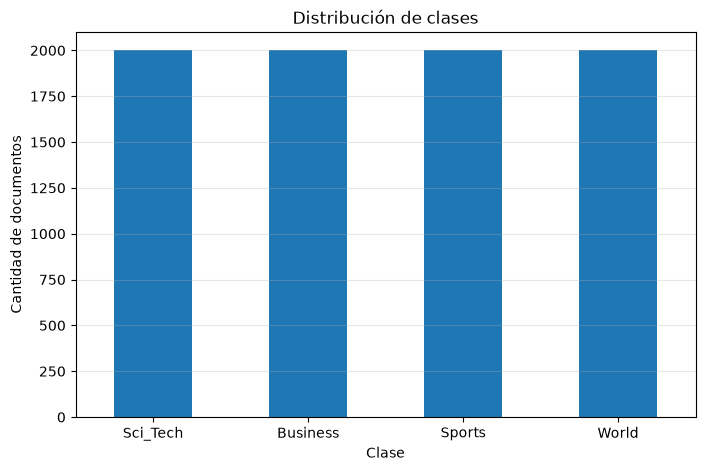

In [24]:
fig = plt.figure(figsize=(8, 5))

conteo_clases.plot(kind="bar")

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad de documentos")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

fig.savefig(
    OUTPUTS_FIGURES / "distribucion_clases.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 18. Resumen de artefactos generados

In [26]:
print("=== Artefactos generados ===")

print("\nCorpus procesado:")
print(DATA_PROCESSED)

print("\nTablas:")
print(OUTPUTS_TABLES)

print("\nFiguras:")
print(OUTPUTS_FIGURES)

print("\nEntrega 2 finalizada correctamente.")

=== Artefactos generados ===

Corpus procesado:
C:\proyecto_nlp_ds3\proyecto_nlp_ds3\data\processed

Tablas:
C:\proyecto_nlp_ds3\proyecto_nlp_ds3\outputs\tables

Figuras:
C:\proyecto_nlp_ds3\proyecto_nlp_ds3\outputs\figures

Entrega 2 finalizada correctamente.
